MSE = 2.116609587399093e-05


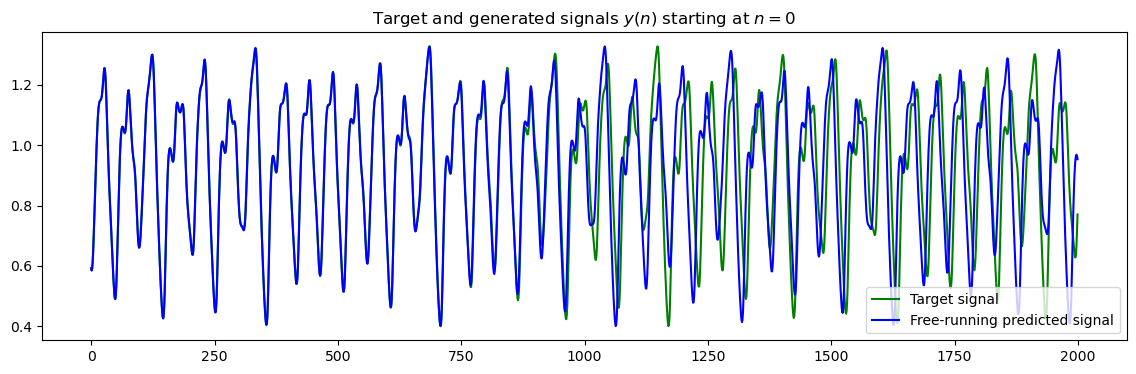

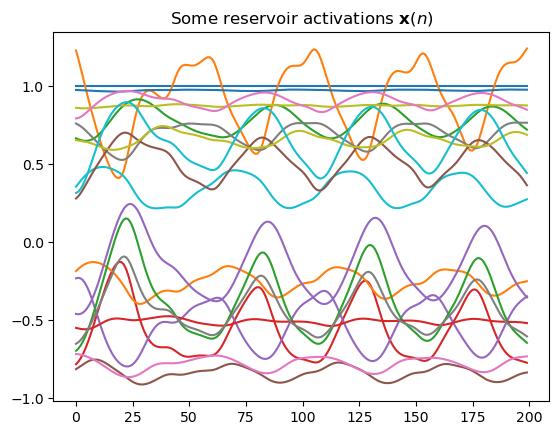

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from reservoirpy.datasets import mackey_glass, lorenz
import networkx as nx

input_size= 1 # dimension of the input
output_size= 1 # dimension of the output
res_size= 200 # dimension of the reservoir

train_len = 1500 
test_len= 2000

spectral_radius= 1.25 # spectral radius of the reservoir matrix
leak_rate= 0.3 # leak rate of the reservoir
input_scaling= 0.5 # input scaling factor

J= 1.0 # scaling factor for gaussian distribution


def load_data(train_len=train_len, test_len=test_len):
    total_len = train_len + test_len + 100  # extra for warm-up
    data = mackey_glass(n_timesteps=total_len, seed=42).reshape(-1)
    return data, train_len, test_len


#create gaussian reservoir
def gaussian_reservoir(input_size=input_size, output_size=output_size, res_size=res_size, J=J, seed=45):
    np.random.seed(seed)
    Win = 2 * (np.random.rand(res_size, 1 + input_size) - 0.5) # input weights between -1 and 1

    W = np.random.normal(0, J / np.sqrt(res_size), (res_size, res_size))
    np.fill_diagonal(W, 0)
    return Win, W


def initialize_reservoir(input_size=input_size, output_size=output_size, res_size=res_size, spectral_radius=spectral_radius, seed=45, J=J):
    np.random.seed(seed)
    Win, W = gaussian_reservoir(input_size=input_size, res_size=res_size, J=J, seed=seed)
    rhoW = max(abs(linalg.eig(W)[0]))
    W *= spectral_radius / rhoW
    return Win, W

def run_reservoir(data, Win, W, train_len, init_len, leak_rate, res_size):
    X = np.zeros((1 + 1 + res_size, train_len - init_len))  # 1 bias + 1 input + reservoir
    Yt = data[None, init_len+1:train_len+1]
    x = np.zeros((res_size, 1))

    for t in range(train_len):
        u = data[t]
        x = (1 - leak_rate) * x + leak_rate * np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))
        if t >= init_len:
            X[:, t - init_len] = np.vstack((1, u, x))[:, 0]

    return X, Yt, x

def train_output_weights(X, Yt, reg=1e-8):
    Wout = linalg.solve(
        np.dot(X, X.T) + reg * np.eye(X.shape[0]),
        np.dot(X, Yt.T)
    ).T
    return Wout

def run_prediction(data, Win, W, Wout, x, train_len, test_len, leak_rate):
    Y = np.zeros((1, test_len))
    u = data[train_len]
    for t in range(test_len):
        x = (1 - leak_rate) * x + leak_rate * np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))
        y = np.dot(Wout, np.vstack((1, u, x)))
        Y[:, t] = y
        u = y  # generative mode
    return Y

def compute_mse(data, Y, train_len, error_len=500):
    target = data[train_len + 1:train_len + error_len + 1]
    prediction = Y[0, :error_len]
    mse = np.mean((target - prediction) ** 2)
    return mse

def plot_results(data, Y, train_len, test_len, X, Wout, input_size=input_size, res_size=res_size):
    plt.figure(1, figsize=(14, 4))  
    plt.plot(data[train_len + 1:train_len + test_len + 1], 'g')
    plt.plot(Y.T, 'b')
    plt.title('Target and generated signals $y(n)$ starting at $n=0$')
    plt.legend(['Target signal', 'Free-running predicted signal'])

    plt.figure(2).clear()
    plt.plot(X[0:20, 0:200].T)
    plt.title(r'Some reservoir activations $\mathbf{x}(n)$')

data, trainLen, testLen = load_data()

Win, W = initialize_reservoir(input_size=input_size,res_size=res_size)
X, Yt, x = run_reservoir(data, Win, W, trainLen, init_len=100, leak_rate=leak_rate, res_size=res_size)
Wout = train_output_weights(X, Yt)
Y = run_prediction(data, Win, W, Wout, x, trainLen, testLen, leak_rate=leak_rate)

mse = compute_mse(data, Y, trainLen)
print('MSE =', mse)

plot_results(data, Y, trainLen, testLen, X, Wout)